# PART A : LINEAR CLASSIFICATION MODELS 

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import time
from partb import FlexibleNeuralNetwork, NeuralNetworkTrainer, PerformanceVisualizer


## 1. Load and preprocess MNIST data

In [2]:
df = pd.read_csv(r"./MNIST/train.csv")  
X = df.iloc[:, 1:].values / 255.0   
y = df.iloc[:, 0].values          

### Split dataset

In [3]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

### Filtering Dataset for Binary Classification
Logistic Regression
Dataset is filtered into a smaller one where only samples with 0 or 1 are included

In [4]:
def filter_01(X, y):
    idx = np.where((y == 0) | (y == 1))[0]
    return X[idx], y[idx]

X_train01, y_train01 = filter_01(X_train, y_train)
X_test01,  y_test01  = filter_01(X_test, y_test)
X_val01, y_val01 = filter_01(X_val, y_val)

print(f"Train samples: {len(X_train01)}, Val samples: {len(X_val01)}, Test samples: {len(X_test01)}", flush=True)

Train samples: 5289, Val samples: 1764, Test samples: 1763


## 2. Data Loader
Convert to PyTorch DataLoaders
TensorDatase(x,y) groups x and y values into datasets like Python tuples (features, label)
batch_size defines how many datasets are included in each batch, leftover batches are in the last batch

In [5]:
def make_loader(X, y, batch=64):
    X = torch.tensor(X, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(X, y), batch_size=batch, shuffle=True)

train_loader = make_loader(X_train, y_train)
val_loader   = make_loader(X_val, y_val)
test_loader  = make_loader(X_test, y_test)

print("Data Loading completed")

Data Loading completed


## 3. Logistic Regression Model
nn.Module is the base class for all neural network models in PyTorch
The Model is a subclass of it
linear is the flattened MNIST image
self.linear() creates a weight matrix 1x784 and a bias , weights and bias are randmoly initialized by PyTorch
sigmoid() activation function squashes output between 0 and 1 (probability of belonging to class 1)
BCELoss() calculates binary cross entropy loss 
optim.SGD() optimizes output by using Stochastic Gradient Descent 
the parameters() returns all values of weights and biases that can be learned.
learning rate = 0.01

In [6]:
class LogisticRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(784, 1)
    def forward(self, x):
        return torch.sigmoid(self.linear(x))

## 4. Training Function and Validation
- model_log.train() sets model to training mode
- inputs, labels in train01_loader iterate over batches of data
- labels are converted to floats and reshaped to column vectors because bin classification outputs one val per sample
- outputs are the predictions of the model
- loss calculates difference between predictions and true labels
- optimizer.zero_grad(), loss.backward() , optimizer.step() all three clear old gradients, compute new ones and update weights
- running_loss keeps a sum of batch losses
- predicted uses threshold of 0.5 to convert output to the classes 0 and 1
- accuracy calculates correct predictions

- model_log.eval() disables training specific behaviour
- torch.no_grad() disables gradient decent calculator
- calculates accuracy and validation losses

In [7]:
def train_log_model(model_log, train_loader, val_loader, learning_rate, num_epochs = 20):
    criterion = nn.BCELoss()
    optimizer = optim.SGD(model_log.parameters(), lr=learning_rate)
    
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    
    for epoch in range(num_epochs):
        model_log.train()
        running_loss = 0
        correct = 0
        total = 0
        for BATCH_IDC, (inputs, labels) in enumerate(train_loader):
            labels = labels.float().view(-1, 1)
            inputs = inputs.float()
            outputs = model_log(inputs)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            predicted = (outputs > 0.5).float()
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            
        train_losses.append(running_loss / len(train_loader))
        train_accs.append(correct / total)
        
#VALIDATIOM
        model_log.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                labels = labels.float().view(-1, 1)
                inputs = inputs.float()
                outputs = model_log(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                predicted = (outputs > 0.5).float()
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)
        val_losses.append(val_loss / len(val_loader))
        val_accs.append(val_correct / val_total)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accs[-1]:.4f} | "
          f"Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_accs[-1]:.4f}")
    
    return train_losses, val_losses, train_accs, val_accs

## 5. Evaluate function

In [8]:
def evaluate_log_model(model_log, test_loader):
    all_pred, all_true = [], []
    correct, total = 0, 0  # Initialize counters

    model_log.eval()
    with torch.no_grad():
        for x, y in test_loader:
            y_pred = (model_log(x) > 0.5).float().view(-1)
            all_pred.extend(y_pred.numpy())
            all_true.extend(y.numpy())

            # Update counters
            correct += (y_pred == y).sum().item()
            total += y.size(0)

    # Confusion matrix and classification report
    cm = confusion_matrix(all_true, all_pred)
    ConfusionMatrixDisplay(cm).plot()
    plt.show()
    print(classification_report(all_true, all_pred))

    # Return accuracy as a percentage
    return 100 * correct / total

## 6. Main_Log Function to test hyperparameters

In [9]:
def main_log(learning_rate, batch_size, num_epochs=20):
    print("Shapes after filtering:")
    print("X_train01:", X_train01.shape, "y_train01:", y_train01.shape)
    print("X_val01:", X_val01.shape, "y_val01:", y_val01.shape)
    print("X_test01:", X_test01.shape, "y_test01:", y_test01.shape)

    train_loader = make_loader(X_train01, y_train01, batch=batch_size)
    val_loader   = make_loader(X_val01, y_val01, batch=batch_size)

    model_log = LogisticRegression()
    
    train_losses, val_losses, train_accs, val_accs = train_log_model(
        model_log, train_loader, val_loader, learning_rate, num_epochs
    )
    
    return train_losses, val_losses, train_accs, val_accs, model_log
        

## A3. SOFTMAX REGRESSION IMPLEMENTATION
- USE_MANUAL lets either manual softmax or pytorch's built in functions work
- exp_z contains the exponentials of the shifted logits
- exp_z.sum calculates the sum of exponentials across each row

It transforms arbitrary logits into probability distributions over classes, where:
- each element is between 0 and 1 
- all probabilities in each row sum to 1

- cross_entropy() calculates the cross-entropy loss manually to measure of how well the model's predictions are

### 1. Manual Softmax helper functions:

In [10]:
def softmax(z):
    exp_z = torch.exp(z - z.max(dim=1, keepdim=True).values)
    return exp_z / exp_z.sum(dim=1, keepdim=True)

def cross_entropy(pred, target):
    n = pred.shape[0]
    return -torch.log(pred[range(n), target]).mean()

Train and validation Softmax Manual
- W - a learnable feature (Weights)
- b - a learnable bias - initialized to zero

- correct: counts correctly classified examples
- total: total examples seen
- running loss: sum of batch losses for the epoch (float)

- Xb and yb: input and label batch tensors
- logits size is [batch_size, 10]

- loss.backward() is used to calculate gradients wrt paramters that loss depends on

### 2. PyTorch's Model Definition:
- Softmax Regression Model using PyTorch's nn Module
- It maps the 784 inputs to 10 output classes
- We use cross entropy loss function
- Results are optimized using the Stochastic Gradient Descent (SGD) with 0.01 as learning rate. 

In [11]:
class SoftmaxRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(784, 10)
    def forward(self, x):
        return self.linear(x)
model = SoftmaxRegression()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

class ManualSoftmaxModel:
    def __init__(self, W, b):
        self.W = W
        self.b = b


### Training and Validation Loop - Softmax 
- For each epoch, the model performs forward and backward passes on mini-batches from the training data. 
- The loss is computed using CrossEntropyLoss, and gradients are used to update parameters with SGD. 
- After each epoch, performance is evaluated on the validation set. 
- Training and validation losses/accuracies are tracked for monitoring learning progress.


In [12]:
def main_softmax(learning_rate, batch_size, num_epochs=20, use_manual=False):
    train_loader = make_loader(X_train, y_train, batch=batch_size)
    val_loader   = make_loader(X_val, y_val, batch=batch_size)
    
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    
    if use_manual:
        # --- 2a. Manual softmax implementation ---
        W = torch.nn.Parameter(torch.randn(784, 10) * 0.01)
        b = torch.nn.Parameter(torch.zeros(10))
        
        for epoch in range(num_epochs):
            correct, total, running_loss = 0, 0, 0
            for Xb, yb in train_loader:
                logits = Xb @ W + b
                probs = softmax(logits)
                loss = cross_entropy(probs, yb)
                loss.backward()
            
                with torch.no_grad():
                    W -= learning_rate * W.grad
                    b -= learning_rate * b.grad
                    W.grad = None
                    b.grad = None
                
                running_loss += loss.item()
                _, pred = torch.max(probs, 1)
                correct += (pred == yb).sum().item()
                total += yb.size(0)
        
            train_losses.append(running_loss / len(train_loader))
            train_accs.append(100 * correct / total)
        
            # Validation 
            correct, total, vloss = 0, 0, 0
            with torch.no_grad():
                for Xb, yb in val_loader:
                    logits = Xb @ W + b
                    probs = softmax(logits)
                    loss = cross_entropy(probs, yb)
                    vloss += loss.item()
                    _, pred = torch.max(probs, 1)
                    correct += (pred == yb).sum().item()
                    total += yb.size(0)
            val_losses.append(vloss / len(val_loader))
            val_accs.append(100 * correct / total)
        
            print(f"Manual Epoch {epoch+1}: Train Acc={train_accs[-1]:.2f}%, Val Acc={val_accs[-1]:.2f}%")
            
        model_manual = ManualSoftmaxModel(W, b)
        return train_losses, val_losses, train_accs, val_accs, model_manual
        
    else:
        model = SoftmaxRegression()
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.SGD(model.parameters(), lr=learning_rate)
        
        for epoch in range(num_epochs):
            # Training
            correct, total, running_loss = 0, 0, 0
            for Xb, yb in train_loader:
                outputs = model(Xb)
                loss = criterion(outputs, yb)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                
                running_loss += loss.item()
                _, pred = torch.max(outputs, 1)
                correct += (pred == yb).sum().item()
                total += yb.size(0)
            
            train_losses.append(running_loss / len(train_loader))
            train_accs.append(100 * correct / total)
            
            # Validation
            correct, total, vloss = 0, 0, 0
            with torch.no_grad():
                for Xb, yb in val_loader:
                    outputs = model(Xb)
                    loss = criterion(outputs, yb)
                    vloss += loss.item()
                    _, pred = torch.max(outputs, 1)
                    correct += (pred == yb).sum().item()
                    total += yb.size(0)
            val_losses.append(vloss / len(val_loader))
            val_accs.append(100 * correct / total)
            
            print(f"PyTorch Epoch {epoch+1}: Train Acc={train_accs[-1]:.2f}%, Val Acc={val_accs[-1]:.2f}%")
        return train_losses, val_losses, train_accs, val_accs, model
        


### Test Set and Confusion Matrix of Manual Softmax

In [13]:
def softmax_man_evaluate_model(test_loader, W, b):
    all_pred_man, all_true_man = [], []

    with torch.no_grad():
        for x, y in test_loader:
            logits = x @ W + b
            x = x.view(x.size(0), -1)
            probs = softmax(logits)
            _, p = torch.max(probs, 1)
            all_pred_man.extend(p.numpy())
            all_true_man.extend(y.numpy())


    # double-check
    print("Unique predicted labels:", np.unique(all_pred_man))
    print("Unique true labels:", np.unique(all_true_man))

    cm = confusion_matrix(all_true_man, all_pred_man)
    ConfusionMatrixDisplay(cm, display_labels=list(range(10))).plot(cmap="Blues")
    plt.title("Manual Softmax Confusion Matrix")
    plt.show()
    print("Manual Softmax Classification Report:")
    print(classification_report(all_true_man, all_pred_man))

### Test Function and Confusion Matrix of PyTorch Softmax

In [14]:
def softmax_pytorch_evaluate_model(test_loader, model):
    all_pred, all_true = [], []
    correct, total = 0, 0

    model.eval()
    with torch.no_grad():
        for x, y in test_loader:
            _, p = torch.max(model(x), 1)
            all_pred.extend(p.numpy())
            all_true.extend(y.numpy())

            # Update counters
            correct += (p == y).sum().item()
            total += y.size(0)

    # Confusion matrix and classification report
    cm = confusion_matrix(all_true, all_pred)
    ConfusionMatrixDisplay(cm, display_labels=list(range(10))).plot(cmap='Blues')
    plt.title("Softmax MNIST Confusion Matrix")
    plt.show()
    print(classification_report(all_true, all_pred))

    # Return test accuracy as a percentage
    return 100 * correct / total


## 6. Main Function For Logistic Regression -  Softmax Regression

### Learning Rate Analysis 
- Convergence Speed depends on how loss decreases or accuracy increases.
- Stability is defined by the smoothness of the curve: higher LR's curves oscillate or diverge leading to unstable training and slow LR have a smooth, slow and stable training.

### Batch Size Analysis
- Training efficiency describes how fast the model trains: smaller batches need more iterations per epoch and are usually slower per epoch whereas larger batches have fewer iterations per epoch and are that way faster
- Gradient noise: smaller batches have more fluctuations in loss and accuracies per batch.


=== Running Logistic Regression with Learning Rate: 0.001 ===
Shapes after filtering:
X_train01: (5289, 784) y_train01: (5289,)
X_val01: (1764, 784) y_val01: (1764,)
X_test01: (1763, 784) y_test01: (1763,)
Epoch [20/20] Train Loss: 0.0811, Train Acc: 0.9975 | Val Loss: 0.0789, Val Acc: 0.9955

=== Running Logistic Regression with Learning Rate: 0.01 ===
Shapes after filtering:
X_train01: (5289, 784) y_train01: (5289,)
X_val01: (1764, 784) y_val01: (1764,)
X_test01: (1763, 784) y_test01: (1763,)
Epoch [20/20] Train Loss: 0.0138, Train Acc: 0.9987 | Val Loss: 0.0167, Val Acc: 0.9966

=== Running Logistic Regression with Learning Rate: 0.1 ===
Shapes after filtering:
X_train01: (5289, 784) y_train01: (5289,)
X_val01: (1764, 784) y_val01: (1764,)
X_test01: (1763, 784) y_test01: (1763,)
Epoch [20/20] Train Loss: 0.0030, Train Acc: 0.9996 | Val Loss: 0.0067, Val Acc: 0.9972

=== Running Logistic Regression with Learning Rate: 1.0 ===
Shapes after filtering:
X_train01: (5289, 784) y_train01:

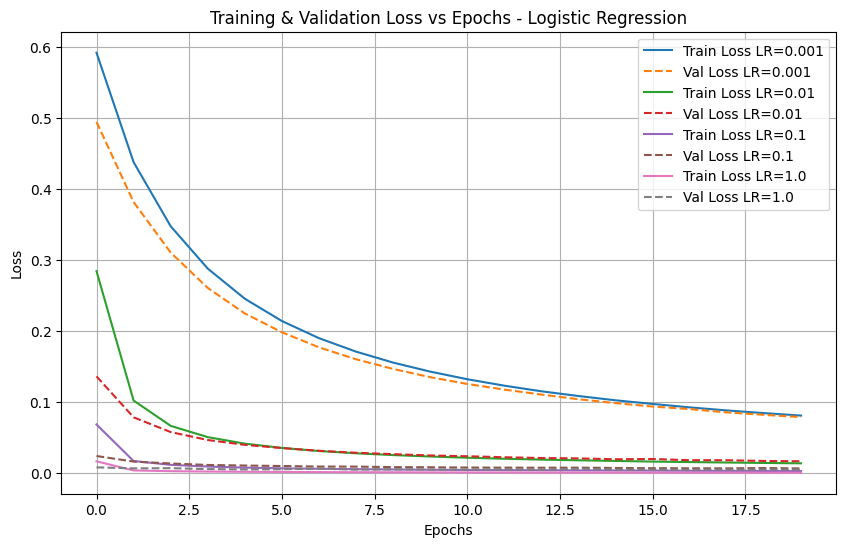

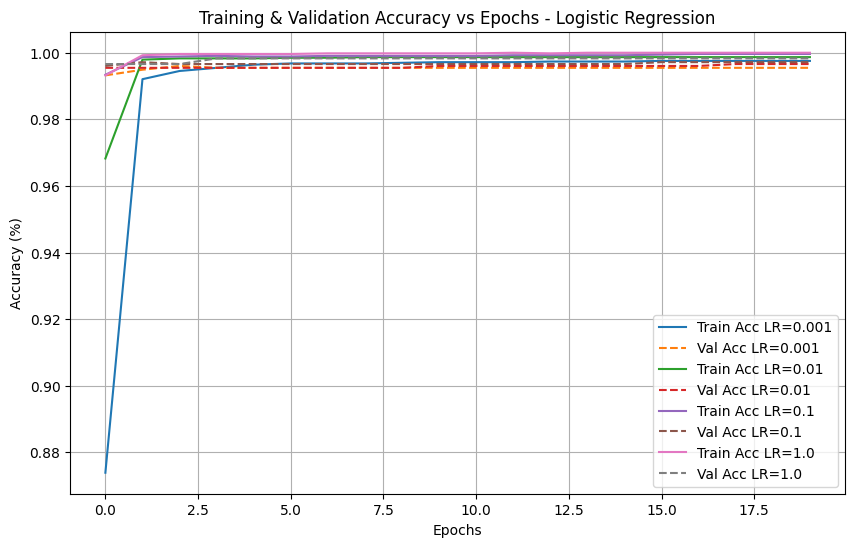


=== Running Logistic Regression with Batch Size: 16 ===
Shapes after filtering:
X_train01: (5289, 784) y_train01: (5289,)
X_val01: (1764, 784) y_val01: (1764,)
X_test01: (1763, 784) y_test01: (1763,)
Epoch [20/20] Train Loss: 0.0054, Train Acc: 0.9991 | Val Loss: 0.0090, Val Acc: 0.9966
Batch size 16 took 5.20 seconds


=== Running Logistic Regression with Batch Size: 32 ===
Shapes after filtering:
X_train01: (5289, 784) y_train01: (5289,)
X_val01: (1764, 784) y_val01: (1764,)
X_test01: (1763, 784) y_test01: (1763,)
Epoch [20/20] Train Loss: 0.0085, Train Acc: 0.9989 | Val Loss: 0.0119, Val Acc: 0.9966
Batch size 32 took 3.24 seconds


=== Running Logistic Regression with Batch Size: 64 ===
Shapes after filtering:
X_train01: (5289, 784) y_train01: (5289,)
X_val01: (1764, 784) y_val01: (1764,)
X_test01: (1763, 784) y_test01: (1763,)
Epoch [20/20] Train Loss: 0.0141, Train Acc: 0.9989 | Val Loss: 0.0167, Val Acc: 0.9960
Batch size 64 took 3.02 seconds


=== Running Logistic Regression w

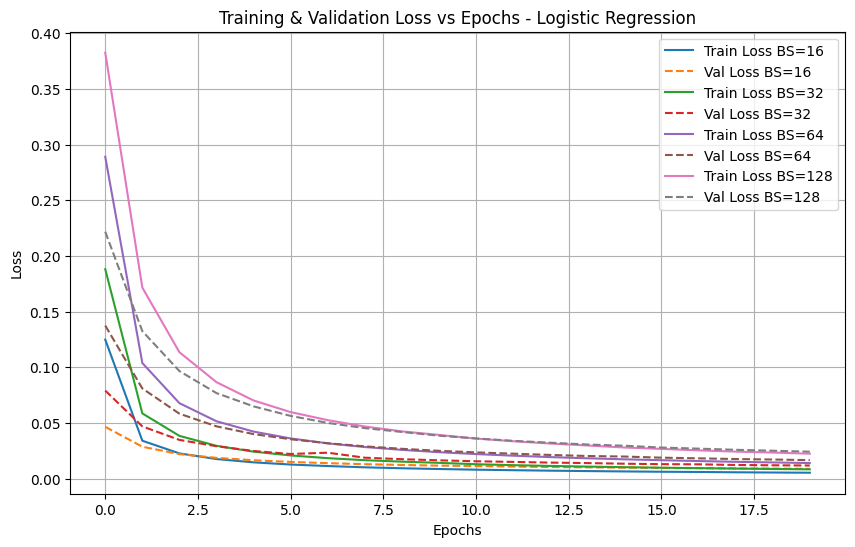

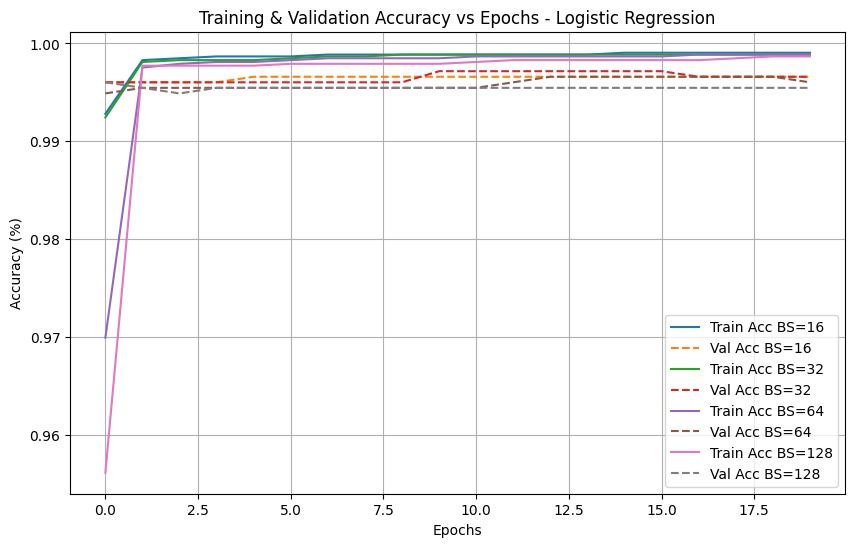

Shapes after filtering:
X_train01: (5289, 784) y_train01: (5289,)
X_val01: (1764, 784) y_val01: (1764,)
X_test01: (1763, 784) y_test01: (1763,)
Epoch [20/20] Train Loss: 0.0140, Train Acc: 0.9987 | Val Loss: 0.0165, Val Acc: 0.9972


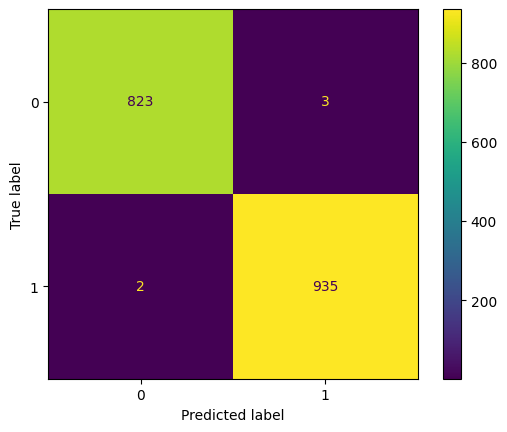

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       826
           1       1.00      1.00      1.00       937

    accuracy                           1.00      1763
   macro avg       1.00      1.00      1.00      1763
weighted avg       1.00      1.00      1.00      1763

Manual Epoch 1: Train Acc=51.31%, Val Acc=69.36%
Manual Epoch 2: Train Acc=73.34%, Val Acc=75.33%
Manual Epoch 3: Train Acc=76.95%, Val Acc=77.55%
Manual Epoch 4: Train Acc=78.61%, Val Acc=78.94%
Manual Epoch 5: Train Acc=79.85%, Val Acc=80.17%
Manual Epoch 6: Train Acc=81.02%, Val Acc=80.83%
Manual Epoch 7: Train Acc=81.69%, Val Acc=81.57%
Manual Epoch 8: Train Acc=82.29%, Val Acc=82.19%
Manual Epoch 9: Train Acc=82.73%, Val Acc=82.75%
Manual Epoch 10: Train Acc=83.25%, Val Acc=82.99%
Manual Epoch 11: Train Acc=83.50%, Val Acc=83.15%
Manual Epoch 12: Train Acc=83.76%, Val Acc=83.33%
Manual Epoch 13: Train Acc=84.07%, Val Acc=83.57%
Manual Epoch 14: Train Acc=84.33

KeyboardInterrupt: 

In [15]:
        
if __name__ == "__main__":
    
    lr_results = {}
    results = {}
    learning_rates = [0.001, 0.01, 0.1, 1.0]
    for lr in learning_rates:
        print(f"\n=== Running Logistic Regression with Learning Rate: {lr} ===", flush=True)
        train_losses, val_losses, train_accs, val_accs, model_log= main_log(learning_rate=lr, batch_size=64, num_epochs=20)
        # Store for plotting
        lr_results[lr] = {
            "train_losses": train_losses,
            "val_losses": val_losses,
            "train_accs": train_accs,
            "val_accs": val_accs 
            }
        
        
    # --- Loss vs Epochs ---
    plt.figure(figsize=(10,6))
    for lr in learning_rates:
        plt.plot(lr_results[lr]["train_losses"], label=f"Train Loss LR={lr}")
        plt.plot(lr_results[lr]["val_losses"], label=f"Val Loss LR={lr}", linestyle='--')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training & Validation Loss vs Epochs - Logistic Regression")
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- Accuracy vs Epochs ---
    plt.figure(figsize=(10,6))
    for lr in learning_rates:
        plt.plot(lr_results[lr]["train_accs"], label=f"Train Acc LR={lr}")
        plt.plot(lr_results[lr]["val_accs"], label=f"Val Acc LR={lr}", linestyle='--')
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy (%)")
    plt.title("Training & Validation Accuracy vs Epochs - Logistic Regression")
    plt.legend()
    plt.grid(True)
    plt.show()


    batch_sizes = [16, 32, 64, 128]
    bs_results = {}  # make sure defined

    for bs in batch_sizes:
        start = time.time()
        print(f"\n=== Running Logistic Regression with Batch Size: {bs} ===", flush=True)
        
        train_losses, val_losses, train_accs, val_accs, model_log = main_log(
            learning_rate=0.01, batch_size=bs, num_epochs=20
        )
        print(f"Batch size {bs} took {time.time() - start:.2f} seconds\n")
        
        # Store results for comparison
        bs_results[bs] = {
            "train_losses": train_losses,
            "val_losses": val_losses,
            "train_accs": train_accs,
            "val_accs": val_accs
        }

    # --- Loss vs Epochs for Different Batch Sizes ---
    plt.figure(figsize=(10,6))
    for bs in batch_sizes:
        plt.plot(bs_results[bs]["train_losses"], label=f"Train Loss BS={bs}")
        plt.plot(bs_results[bs]["val_losses"], label=f"Val Loss BS={bs}", linestyle='--')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training & Validation Loss vs Epochs - Logistic Regression")
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- Accuracy vs Epochs for Different Batch Sizes ---
    plt.figure(figsize=(10,6))
    for bs in batch_sizes:
        plt.plot(bs_results[bs]["train_accs"], label=f"Train Acc BS={bs}")
        plt.plot(bs_results[bs]["val_accs"], label=f"Val Acc BS={bs}", linestyle='--')
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy (%)")
    plt.title("Training & Validation Accuracy vs Epochs - Logistic Regression")
    plt.legend()
    plt.grid(True)
    plt.show()

    #Final evaluation
    best_lr = 0.01
    best_batch_size = 64

    # Re-train model with best hyperparameters
    start_time = time.time()
    train_losses, val_losses, train_accs, val_accs, best_model = main_log(
    learning_rate=best_lr, batch_size=best_batch_size, num_epochs=20
    )
    end_time = time.time()
    training_time_logistic= end_time - start_time
    val_accs_logistic = val_accs

    # Create test loader with the same batch size
    test_loader = make_loader(X_test01, y_test01, batch=best_batch_size)

    # Call evaluate_log_model to show confusion matrix & metrics
    accuracy_logistic = evaluate_log_model(best_model, test_loader)
    
    #--- SOFTMAX ---
    #manual softmax
    lr_softmax_man_results = {}
    for lr in learning_rates:
        train_losses, val_losses, train_accs, val_accs, model = main_softmax(
            learning_rate=lr, batch_size=64, num_epochs=20, use_manual=True
        )
        lr_softmax_man_results[lr] = {
            "train_losses": train_losses,
            "val_losses": val_losses,
            "train_accs": train_accs,
            "val_accs": val_accs
        }
    
    #pytorch softmax
    lr_softmax_pyt_results = {}
    for lr in learning_rates:
        train_losses, val_losses, train_accs, val_accs, model = main_softmax(
            learning_rate=lr, batch_size=64, num_epochs=20, use_manual=False
        )
        lr_softmax_pyt_results[lr] = {
            "train_losses": train_losses,
            "val_losses": val_losses,
            "train_accs": train_accs,
            "val_accs": val_accs
        }
        
    
    # Plot Training Loss for manual vs PyTorch softmax
    plt.figure(figsize=(10,6))
    for lr in learning_rates:
        plt.plot(lr_softmax_man_results[lr]["train_losses"], label=f"Manual Train Loss LR={lr}")
        plt.plot(lr_softmax_pyt_results[lr]["train_losses"], "--", label=f"PyTorch Train Loss LR={lr}")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Softmax Training Loss vs Epochs (Manual vs PyTorch)")
    plt.legend()
    plt.show()

    # Plot Validation Loss
    plt.figure(figsize=(10,6))
    for lr in learning_rates:
        plt.plot(lr_softmax_man_results[lr]["val_losses"], label=f"Manual Val Loss LR={lr}")
        plt.plot(lr_softmax_pyt_results[lr]["val_losses"], "--", label=f"PyTorch Val Loss LR={lr}")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Softmax Validation Loss vs Epochs (Manual vs PyTorch)")
    plt.legend()
    plt.show()

    # Plot Training Accuracy
    plt.figure(figsize=(10,6))
    for lr in learning_rates:
        plt.plot(lr_softmax_man_results[lr]["train_accs"], label=f"Manual Train Acc LR={lr}")
        plt.plot(lr_softmax_pyt_results[lr]["train_accs"], "--", label=f"PyTorch Train Acc LR={lr}")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Softmax Training Accuracy vs Epochs (Manual vs PyTorch)")
    plt.legend()
    plt.show()

    # Plot Validation Accuracy
    plt.figure(figsize=(10,6))
    for lr in learning_rates:
        plt.plot(lr_softmax_man_results[lr]["val_accs"], label=f"Manual Val Acc LR={lr}")
        plt.plot(lr_softmax_pyt_results[lr]["val_accs"], "--", label=f"PyTorch Val Acc LR={lr}")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Softmax Validation Accuracy vs Epochs (Manual vs PyTorch)")
    plt.legend()
    plt.show()

    # --- SOFTMAX BATCH SIZE ANALYSIS --- 
    batch_sizes = [16, 32, 64, 128]

    # Manual Softmax
    bs_softmax_man_results = {}
    for bs in batch_sizes:
        train_losses, val_losses, train_accs, val_accs, model = main_softmax(
            learning_rate=0.01, batch_size=bs, num_epochs=20, use_manual=True
        )
        bs_softmax_man_results[bs] = {
            "train_losses": train_losses,
            "val_losses": val_losses,
            "train_accs": train_accs,
            "val_accs": val_accs
        }

    # PyTorch Softmax
    bs_softmax_pyt_results = {}
    for bs in batch_sizes:
        train_losses, val_losses, train_accs, val_accs, model = main_softmax(
            learning_rate=0.01, batch_size=bs, num_epochs=20, use_manual=False
        )
        bs_softmax_pyt_results[bs] = {
            "train_losses": train_losses,
            "val_losses": val_losses,
            "train_accs": train_accs,
            "val_accs": val_accs
        }

    # --- Training Loss vs Epochs ---
    plt.figure(figsize=(10,6))
    for bs in batch_sizes:
        plt.plot(bs_softmax_man_results[bs]["train_losses"], label=f"Manual Train Loss BS={bs}")
        plt.plot(bs_softmax_pyt_results[bs]["train_losses"], "--", label=f"PyTorch Train Loss BS={bs}")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Softmax Training Loss vs Epochs (Manual vs PyTorch)")
    plt.legend()
    plt.show()

    # --- Validation Loss vs Epochs ---
    plt.figure(figsize=(10,6))
    for bs in batch_sizes:
        plt.plot(bs_softmax_man_results[bs]["val_losses"], label=f"Manual Val Loss BS={bs}")
        plt.plot(bs_softmax_pyt_results[bs]["val_losses"], "--", label=f"PyTorch Val Loss BS={bs}")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Softmax Validation Loss vs Epochs (Manual vs PyTorch)")
    plt.legend()
    plt.show()

    # --- Training Accuracy vs Epochs ---
    plt.figure(figsize=(10,6))
    for bs in batch_sizes:
        plt.plot(bs_softmax_man_results[bs]["train_accs"], label=f"Manual Train Acc BS={bs}")
        plt.plot(bs_softmax_pyt_results[bs]["train_accs"], "--", label=f"PyTorch Train Acc BS={bs}")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Softmax Training Accuracy vs Epochs (Manual vs PyTorch)")
    plt.legend()
    plt.show()

    # --- Validation Accuracy vs Epochs ---
    plt.figure(figsize=(10,6))
    for bs in batch_sizes:
        plt.plot(bs_softmax_man_results[bs]["val_accs"], label=f"Manual Val Acc BS={bs}")
        plt.plot(bs_softmax_pyt_results[bs]["val_accs"], "--", label=f"PyTorch Val Acc BS={bs}")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Softmax Validation Accuracy vs Epochs (Manual vs PyTorch)")
    plt.legend()
    plt.show()
    
    # Create the test loader
    test_loader = make_loader(X_test, y_test, batch=64)
    

    # --- Manual Softmax on Test Set---
    train_losses, val_losses, train_accs, val_accs, model_manual= main_softmax(
        learning_rate=0.01, batch_size=64, num_epochs=20, use_manual=True
    )
    softmax_man_evaluate_model(test_loader, model_manual.W, model_manual.b)

    # --- PyTorch Softmax on Test Set---
    start_time = time.time()
    train_losses, val_losses, train_accs, val_accs, model_pyt = main_softmax(
        learning_rate=0.01, batch_size=64, num_epochs=20, use_manual=False
    )
    end_time = time.time()
    training_time_softmax= end_time - start_time
    val_accs_softmax = val_accs
    accuracy_softmax = softmax_pytorch_evaluate_model(test_loader, model_pyt)
    
    
    
    
    
    ## NEURAL NETWORK

    # --- Architecture comparison ---
    hidden_layer_counts = [2, 3, 4, 5]  # number of hidden layers
    neurons_per_layer = [64, 128, 256, 512]  # neurons per hidden layer
    arch_results = []

    for n_layers in hidden_layer_counts:
        for n_neurons in neurons_per_layer:
            layer_sizes = [784] + [n_neurons]*n_layers + [10]
            print(f"\n Training NN with {n_layers} hidden layers and {n_neurons} neurons/layer")

            # Initialize model and trainer
            model = FlexibleNeuralNetwork(layer_sizes, activation='relu', dropout_rate=0.3)
            trainer = NeuralNetworkTrainer(model, learning_rate=0.001, batch_size=128)

            # Train model
            history = trainer.train(X, y, epochs=10, val_split=0.2)
            trainer.load_best_model()

            # Save architecture results
            arch_results.append({
                'hidden_layers': n_layers,
                'neurons_per_layer': n_neurons,
                'train_acc': history['train_acc'][-1],
                'val_acc': history['val_acc'][-1],
                'train_loss': history['train_loss'][-1],
                'val_loss': history['val_loss'][-1],
                'history': history  # save history in case you want to plot per-architecture
            })

            # Print & plot training curves for this architecture
            print(f"\n Metrics for {n_layers} hidden layers, {n_neurons} neurons/layer")
            PerformanceVisualizer.plot_training_curves(history, print_output=True)

    # --- Show comparison table ---
    
    arch_table = pd.DataFrame([{k:v for k,v in r.items() if k != 'history'} for r in arch_results])
    print("\nArchitecture Comparison Table:")
    print(arch_table)

    # --- Pick best architecture based on validation accuracy ---
    best_arch = max(arch_results, key=lambda x: x['val_acc'])
    print(f"\nBest architecture: {best_arch['hidden_layers']} hidden layers, "
        f"{best_arch['neurons_per_layer']} neurons/layer")

    # --- Re-train best model on full training set ---
    layer_sizes = [784] + [best_arch['neurons_per_layer']] * best_arch['hidden_layers'] + [10]
    best_model = FlexibleNeuralNetwork(layer_sizes, activation='relu', dropout_rate=0.3)
    trainer = NeuralNetworkTrainer(best_model, learning_rate=0.001, batch_size=128)
    start_time = time.time()
    history = trainer.train(X, y, epochs=10, val_split=0.2)
    trainer.load_best_model()
    end_time = time.time()
    training_time_neural = end_time - start_time
    validation_acc_neural = best_arch['val_acc']
    best_hidden_layers = best_arch['hidden_layers']
    best_neurons = best_arch['neurons_per_layer'] 
    
    
    # --- Evaluate best model on test set ---
    test_loader = DataLoader(TensorDataset(torch.FloatTensor(X_test), torch.LongTensor(y_test)),
                            batch_size=128, shuffle=False)

    best_model.eval()
    correct, total = 0, 0
    all_pred, all_true = [], []
    with torch.no_grad():
        for Xb, yb in test_loader:
            outputs = best_model(Xb)
            _, predicted = torch.max(outputs, 1)
            total += yb.size(0)
            correct += (predicted == yb).sum().item()
            all_pred.extend(predicted.numpy())
            all_true.extend(yb.numpy())

    test_acc_neural = 100 * correct / total
    print(f"\nTest Accuracy: {test_acc_neural:.2f}%")
    

    # --- Confusion matrix and classification report ---
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

    cm = confusion_matrix(all_true, all_pred)
    ConfusionMatrixDisplay(cm, display_labels=list(range(10))).plot(cmap='Blues')
    plt.title("Test Set Confusion Matrix")
    plt.show()

    print("\nClassification Report:")
    print(classification_report(all_true, all_pred))

### COMPARATIVE ANALYSIS OF THE MODELS
We compare Logistics Regression, Softmax Regression (manual and PyTorch) and the best Neural Network on the MNIST binary subset (digits 0 and 1) and full 10-class dataset.

Key aspects for comparison:
- Accuracy (train, validation, test)
- Training time
- Computational complexity
- Strengths and weaknesses

Key Takeaways:
- Logistic regression is fastest but may struggle with complex patterns.
- Logistic regression is limited to problems with binary classification and cannot model more complex linear relationships.
- Softmax regression generalizes better to multi-class problems, still lightweight but may underperform if data has complex nonlinear patterns. 
- Neural Networks handle non-linearities and complex features, but require longer training and more hyperparameter tuning and is more prone to overfitting.
- Computational complexity increases from Logistic → Softmax → Neural Network.

In [ ]:
# Collect results from previous experiments
results_summary = [
    {
        "Model": "Logistic Regression - LR 0.01, Batch 64",
        "Val Acc (%)": val_accs_logistic[-1]*100,
        "Test Acc (%)": accuracy_logistic,
        "Training Time (s)": training_time_logistic
    },
    {
        "Model": "Softmax (PyTorch) Regression",
        "Val Acc (%)": val_accs_softmax[-1],
        "Test Acc (%)": accuracy_softmax,
        "Training Time (s)": training_time_softmax
    },
    {
        "Model": f"Best Neural Network - {best_hidden_layers} layers, {best_neurons} neurons/layer",
        "Val Acc (%)": validation_acc_neural,
        "Test Acc (%)": test_acc_neural,
        "Training Time (s)": training_time_neural
    }
]

summary_df = pd.DataFrame(results_summary)
print("Performance Comparison Summary:")
display(summary_df)


Performance Comparison Summary:


,Model,Val Acc (%),Test Acc (%),Training Time (s)
0,"Logistic Regression - LR 0.01, Batch 64",99.603175,99.716393,1.821424
1,Softmax (PyTorch) Regression,89.904762,90.190476,9.986189
2,"Best Neural Network - 2 layers, 512 neurons/layer",97.797619,99.404762,21.459193
